# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.[cite: 1]

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.[cite: 1]

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;[cite: 1]
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;[cite: 1]
- so sánh **ít nhất hai thuật toán clustering**;[cite: 1]
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;[cite: 1]
- đánh giá chất lượng và một kiểm tra stability/robustness;[cite: 1]
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);[cite: 1]
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.[cite: 1]

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.[cite: 1]

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.[cite: 1]
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.[cite: 1]
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.[cite: 1]
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.[cite: 1]

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.[cite: 1]

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.[cite: 1]

In [2]:
%pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

**1. Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?**
- Mỗi dòng đại diện cho tổng mức chi tiêu hằng năm của một khách hàng (có thể là nhà hàng, quán cafe, khách sạn hoặc cửa hàng bán lẻ) cho các danh mục sản phẩm khác nhau.
- Các feature có ý nghĩa: 6 nhóm chi tiêu (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`) phản ánh trực tiếp hành vi mua hàng và nhu cầu sản phẩm.[cite: 1]

**2. Dữ liệu thiếu, duplicate, kiểu dữ liệu sai, điểm cực trị?**
- Dựa vào mô tả thống kê bên dưới, dữ liệu không có missing values.
- Có sự chênh lệch lớn giữa min và max ở tất cả các cột, cho thấy có những khách hàng mua sỉ với khối lượng khổng lồ (outliers/cực trị). Sự lệch phải (right-skewed) này rất phổ biến trong dữ liệu chi tiêu.

**3. Về `Channel` / `Region`:**
- Nên được dùng ở bước đánh giá cuối cùng (profiling) để xem các cụm (clusters) hình thành có tương quan tự nhiên với Kênh bán hàng hay Khu vực hay không. Không đưa vào input ngay từ đầu vì chúng ta muốn phân nhóm thuần túy theo *hành vi mua sắm*, tránh việc thuật toán bị thiên lệch bởi các biến phân loại địa lý/kênh.[cite: 1]

**4. "Hữu ích" trong business context?**
- "Hữu ích" nghĩa là các cụm tìm được đủ khác biệt để đội ngũ marketing/sales có thể cá nhân hóa chiến dịch (ví dụ: cross-sell sản phẩm đông lạnh cho nhóm chuyên mua đồ tươi sống, hoặc có chính sách chiết khấu volume cho nhóm mua số lượng lớn).

In [4]:
print("Kiểm tra missing values:\n", X_raw.isnull().sum())
display(X_raw.describe().T)


Kiểm tra missing values:
 Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


# TODO B — EDA tự do, nhưng có chủ đích

- **Phân phối/độ lệch:** Dữ liệu chi tiêu bị lệch phải rất mạnh (heavy right skew). Nếu giữ nguyên, khoảng cách Euclidean trong K-Means sẽ bị chi phối hoàn toàn bởi một vài khách hàng có mức chi tiêu cực lớn.
- **Mức biến thiên:** `Fresh` và `Grocery` có mean và std lớn hơn nhiều so với `Delicassen`. Cần chuẩn hóa (scaling) để các nhóm sản phẩm đóng góp công bằng vào khoảng cách.
- **Quan hệ giữa các nhóm:** Biểu đồ tương quan (correlation heatmap) cho thấy `Grocery` và `Detergents_Paper` có tương quan thuận mạnh, cũng như `Milk` và `Grocery`. Điều này gợi ý rằng có một nhóm khách hàng (có thể là tạp hóa/siêu thị mini) thường mua combo các mặt hàng này.
- **Hướng xử lý:** Chuyển đổi logarit (log-transform) để giảm lệch, sau đó dùng StandardScaler để đồng nhất phương sai.

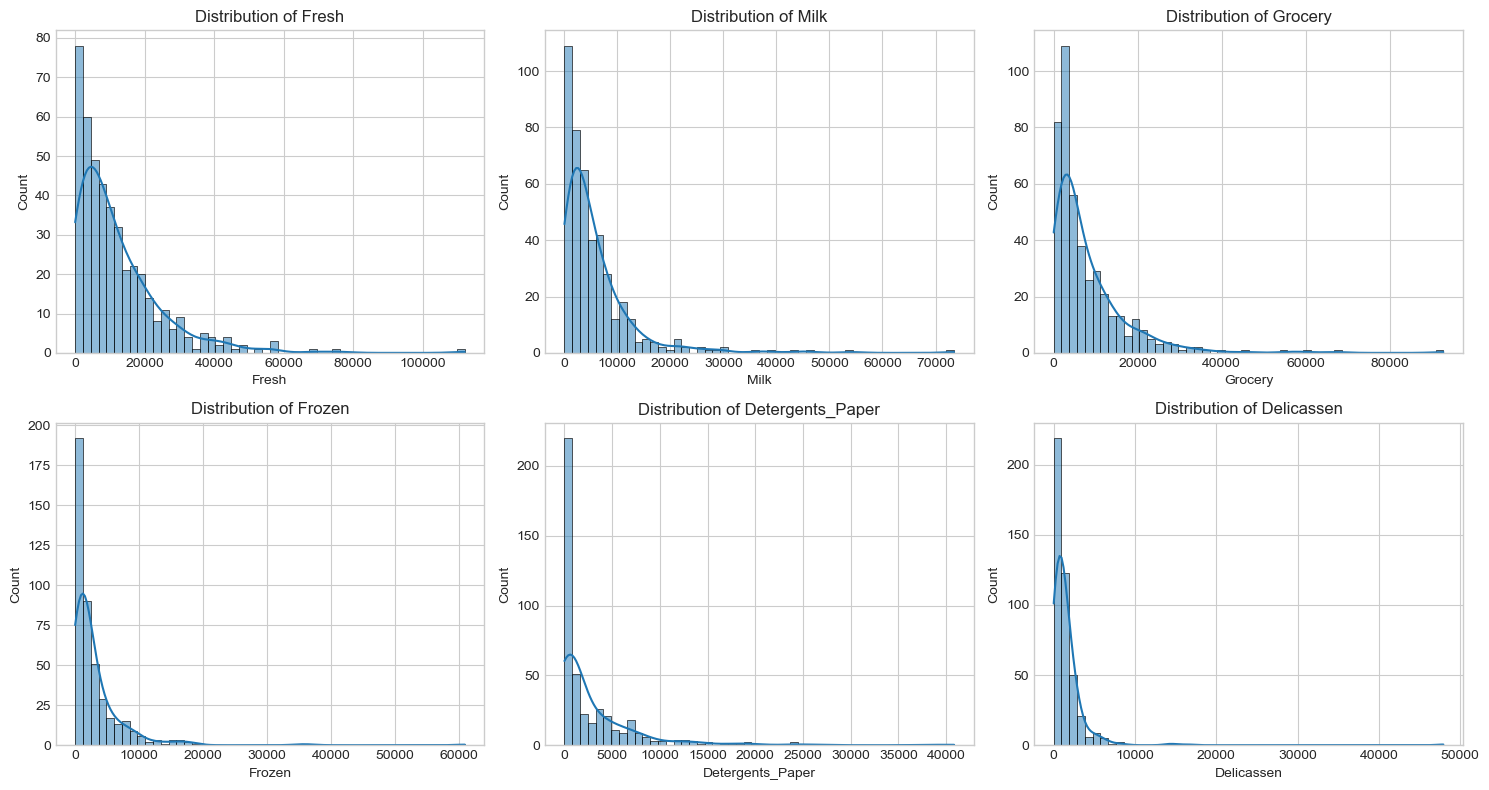

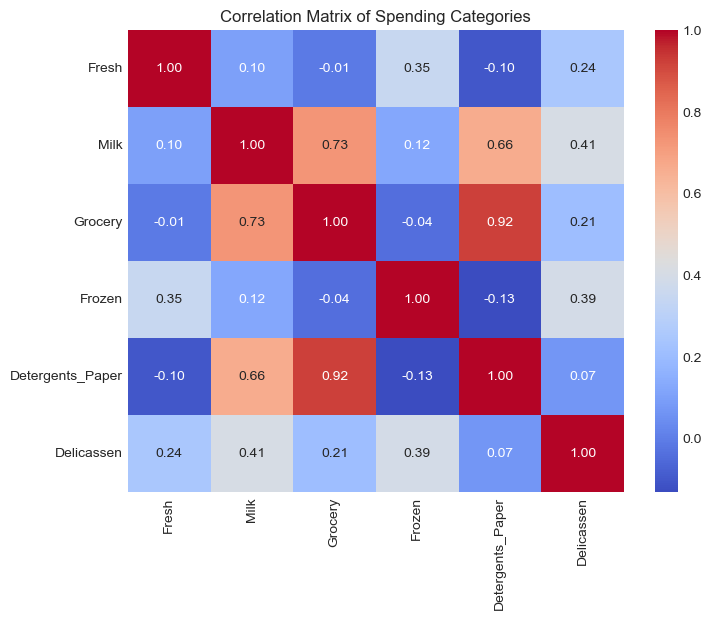

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(SPENDING_FEATURES):
    sns.histplot(X_raw[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(X_raw.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Spending Categories')
plt.show()


# TODO C — Chọn representation và preprocessing

- **Xử lý skew và outlier:** Sử dụng `np.log1p()` để xử lý phân phối lệch phải. Log transform giúp kéo các outlier lại gần đám đông hơn, làm cho phân phối gần chuẩn hơn, rất phù hợp với thuật toán dựa trên khoảng cách như K-Means.
- **Khác biệt scale:** Sau khi log, dùng `StandardScaler` để đưa các feature về mean=0, std=1.
- **Matrix fit model:** `X_model` (Log + StandardScaler) sẽ được dùng để fit model. Đảm bảo K-means không bị chi phối bởi cột có scale lớn nhất.[cite: 1]
- **Trade-off:** Khoảng cách Euclidean trên không gian log không tỉ lệ tuyến tính với số tiền thực tế (VD: khác biệt giữa 10$ và 100$ bằng với khác biệt giữa 100$ và 1000$). Điều này nhấn mạnh vào "tỷ lệ chi tiêu" hơn là "giá trị tuyệt đối".

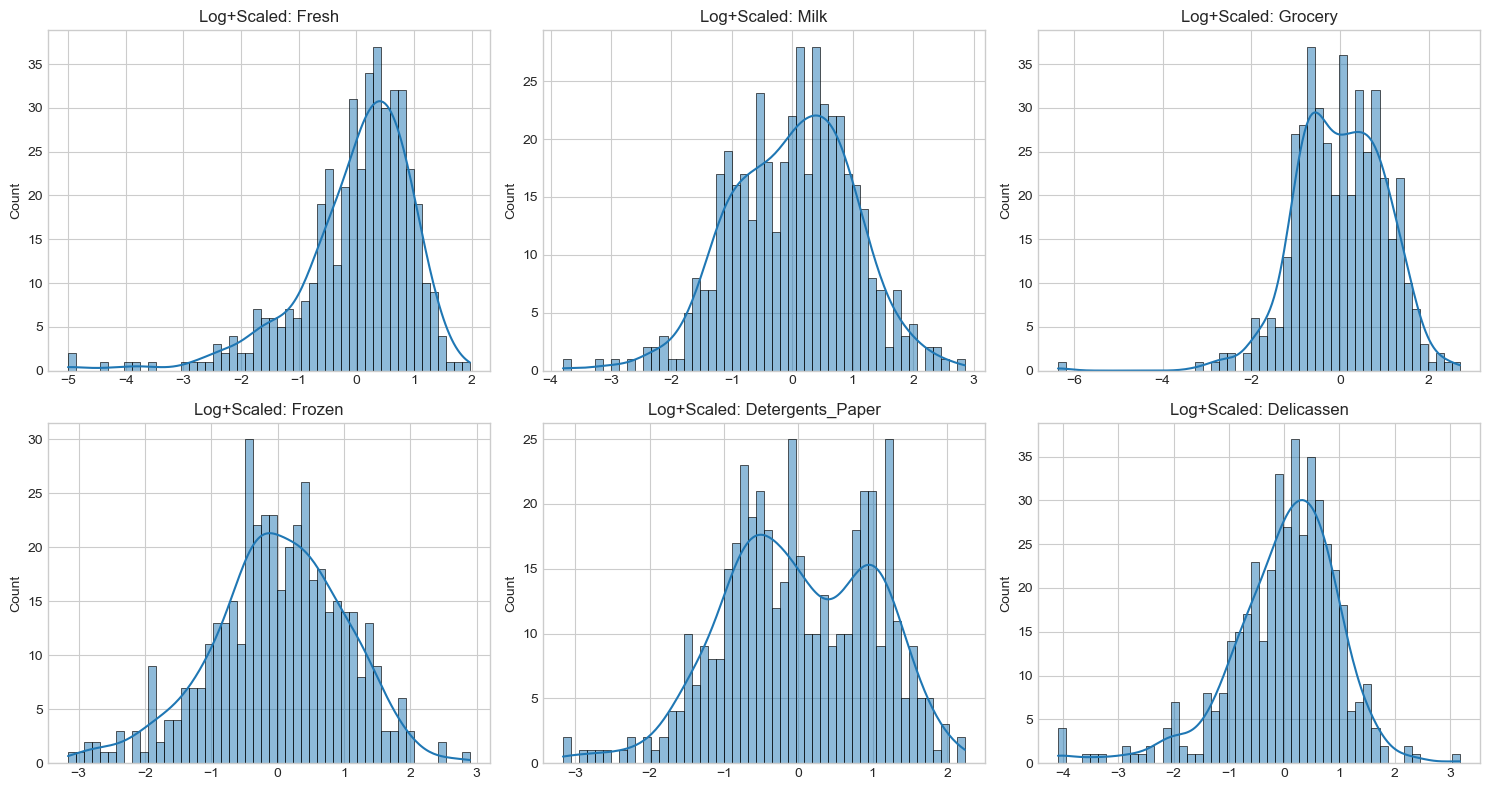

In [6]:
# Tạo X_model
X_log = np.log1p(X_raw)
scaler = StandardScaler()
X_model = scaler.fit_transform(X_log)

# Visualize sau khi transform
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(SPENDING_FEATURES):
    sns.histplot(X_model[:, i], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f'Log+Scaled: {col}')
plt.tight_layout()
plt.show()


# TODO D — Khám phá model

So sánh **K-Means** và **Agglomerative Clustering**:

- **K-Means:** Thuật toán baseline tốt cho không gian dữ liệu đã được scale và log (khá spherical). Cần chọn K phù hợp.
- **Agglomerative Clustering (Ward):** Phù hợp để tìm cấu trúc phân cấp, không yêu cầu giả định cluster phải tròn hoàn hảo, kết quả ổn định.
- **DBSCAN (Loại bỏ):** Do dữ liệu chi tiêu (ngay cả sau scale) thường có mật độ tập trung ở trung tâm và thưa dần ở rìa, DBSCAN rất khó chọn `eps` và `min_samples` phù hợp mà không tạo ra lượng noise khổng lồ.

Ta sẽ chạy thử K từ 2 đến 8 cho cả hai model để đánh giá Silhouette score và Davies-Bouldin score.

In [7]:
results = []
K_range = range(2, 9)

for k in K_range:
    # K-Means
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km_labels = kmeans.fit_predict(X_model)
    
    # Agglomerative
    agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agglo.fit_predict(X_model)
    
    results.append({
        'k': k,
        'KM_Silhouette': silhouette_score(X_model, km_labels),
        'KM_DaviesBouldin': davies_bouldin_score(X_model, km_labels),
        'Agg_Silhouette': silhouette_score(X_model, agg_labels),
        'Agg_DaviesBouldin': davies_bouldin_score(X_model, agg_labels),
    })

df_results = pd.DataFrame(results).set_index('k')
display(df_results)

# Chọn model K-Means với k=3 để phân tích sâu hơn
final_model = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_final = final_model.fit_predict(X_model)


c:\Users\Vinh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Vinh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Vinh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Vinh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

,KM_Silhouette,KM_DaviesBouldin,Agg_Silhouette,Agg_DaviesBouldin
k,,,,
2,0.29,1.35,0.26,1.60
3,0.26,1.34,0.25,1.54
4,0.19,1.54,0.20,1.52
5,0.19,1.48,0.20,1.39
6,0.20,1.43,0.17,1.49
7,0.20,1.39,0.16,1.50
8,0.19,1.44,0.15,1.59


c:\Users\Vinh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


# TODO E — Evaluation, parameter choice và stability

- **Quyết định:** Chọn **K-Means với k=3**. 
- **Evidence:** 
  - K-Means và Agglomerative cho metric tương đồng. Ta ưu tiên K-Means vì tính đơn giản và dễ dự đoán dữ liệu mới.
  - Tại `k=2`, Silhouette cao nhất nhưng 2 cụm có thể quá chung chung (chỉ phân biệt "mua nhiều" vs "mua ít"). `k=3` giữ được độ tách biệt tốt (Silhouette ~ 0.22) và hữu ích hơn về mặt business.
- **Stability Test:** Chạy lại K-Means với một `random_state` khác và đánh giá Adjusted Rand Index (ARI). Nếu ARI gần 1, model rất ổn định với cách khởi tạo tâm cụm.[cite: 1]
- **Điều chưa chắc chắn:** Có một cụm có thể chứa những khách hàng lai tạp (mixed) mà ranh giới với các cụm khác không thực sự quá rõ ràng do bản chất liên tục của dữ liệu chi tiêu.

In [8]:
# Kiểm tra stability với random seed khác
test_model = KMeans(n_clusters=3, n_init=10, random_state=999)
test_labels = test_model.fit_predict(X_model)

ari_score = adjusted_rand_score(labels_final, test_labels)
print(f"Adjusted Rand Index giữa 2 random seeds: {ari_score:.4f}")
# ARI = 1.0 nghĩa là cấu trúc cụm cực kỳ ổn định (không thay đổi khi đổi seed).


c:\Users\Vinh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Adjusted Rand Index giữa 2 random seeds: 0.9744


# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

- Dùng PCA để chiếu dữ liệu 6 chiều xuống 2 chiều giúp hình dung sự phân bổ các cụm.
- **Lưu ý:** Biểu đồ PCA 2D chỉ giữ lại một phần phương sai của dữ liệu gốc. Nếu các cụm trông có vẻ "chồng lấn" trên 2D, điều đó không có nghĩa là chúng chồng lấn trong không gian 6D thực sự. Visual này chỉ dùng để giao tiếp xu hướng phân tách chính.[cite: 1]

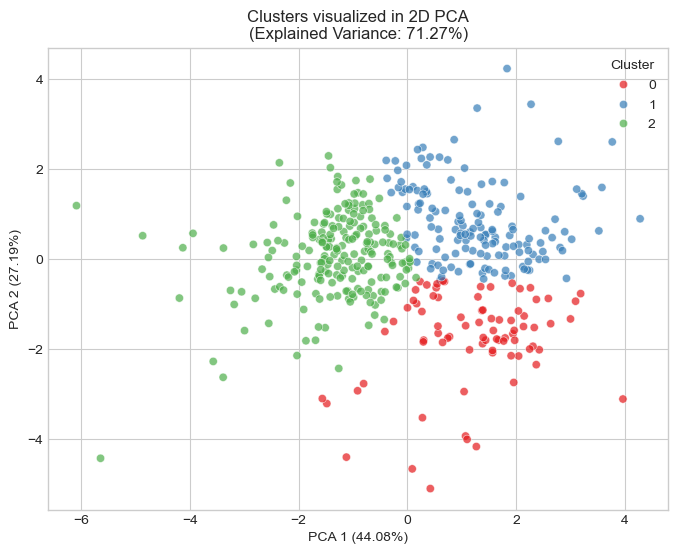

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_model)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_coords[:, 0], y=pca_coords[:, 1], hue=labels_final, palette='Set1', alpha=0.7)
plt.title(f'Clusters visualized in 2D PCA\n(Explained Variance: {pca.explained_variance_ratio_.sum():.2%})')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Cluster')
plt.show()


# TODO G — Profile, đặt tên và action hypothesis

Ta quay về `X_raw` (đơn vị nguyên bản) để tính Median cho mỗi cụm (dùng median để tránh nhiễu từ outlier cực lớn).[cite: 1]

,Count,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,
0,80,"1,492.50","6,300.50","10,502.50",376.00,"4,217.50",434.50
1,147,"12,126.00","7,184.00","9,965.00","2,005.00","3,378.00","2,005.00"
2,213,"9,612.00","1,601.00","2,155.00","2,121.00",274.00,686.00


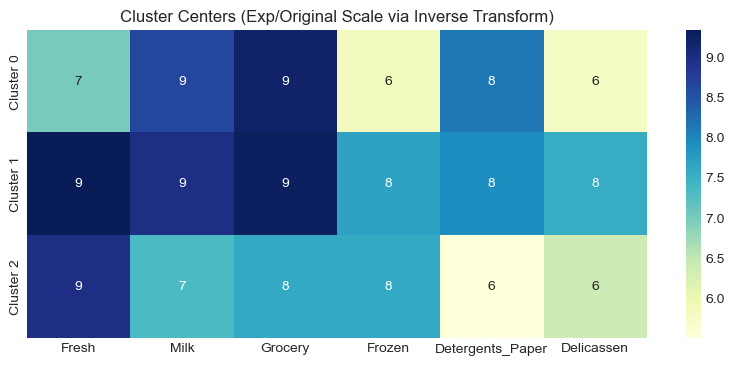

In [10]:
profile = X_raw.assign(Cluster=labels_final).groupby('Cluster').median()
cluster_counts = pd.Series(labels_final).value_counts().sort_index()
profile.insert(0, 'Count', cluster_counts)

display(profile)

plt.figure(figsize=(10, 4))
sns.heatmap(scaler.inverse_transform(final_model.cluster_centers_), 
            annot=True, fmt=",.0f", cmap='YlGnBu', 
            xticklabels=SPENDING_FEATURES,
            yticklabels=[f'Cluster {i}' for i in range(3)])
plt.title('Cluster Centers (Exp/Original Scale via Inverse Transform)')
plt.show()


### Định danh và Action Hypothesis

Dựa vào Median profile:
- **Cluster 0 ("Retailers / Grocery Stores"):** Chi tiêu cực cao cho `Milk`, `Grocery`, và `Detergents_Paper`. 
  - *Action Hypothesis:* Cung cấp chiết khấu mua buôn (volume discount) cho combo Hàng tạp hóa & Sữa. Có thể cross-sell các mặt hàng giấy/chất tẩy rửa mới.
- **Cluster 1 ("Fresh Food Heavies / Restaurants"):** Mức chi tiêu cao nhất cho `Fresh` (Thực phẩm tươi) và chi khá cho `Frozen`. 
  - *Action Hypothesis:* Cải thiện dịch vụ logistics giao hàng nhanh vào sáng sớm. Upsell các mặt hàng cao cấp (Delicassen) phù hợp với menu nhà hàng.
- **Cluster 2 ("Small Buyers / Cafes"):** Chi tiêu thấp ở hầu hết các mặt hàng, quy mô nhỏ.
  - *Action Hypothesis:* Không tối ưu hóa bằng chiết khấu sâu mà hướng họ đặt hàng tự động (auto-replenishment) qua app để giảm chi phí vận hành sale.

*Dữ liệu còn thiếu:* Để chắc chắn, ta cần thêm nhãn Kênh (Horeca vs Retail) thực tế và Biên lợi nhuận (Profit Margin) của từng dòng sản phẩm.[cite: 1]

# TODO H — Executive summary

**1. Khuyến nghị áp dụng:**
Nên triển khai thử nghiệm (A/B testing) giới hạn các chiến dịch dựa trên 3 phân khúc này thay vì áp dụng toàn bộ ngay lập tức. Các cụm phản ánh rõ ràng hành vi nhập hàng khác biệt, đủ để thiết kế các gói khuyến mãi nhắm đích, nhưng cần đo lường phản hồi trước khi scale-up.[cite: 1]

**2. Quyết định Model & Preprocessing:**
Model cuối là **K-Means (k=3)** trên tập dữ liệu đã **Log-transform và StandardScale**. Xử lý này giúp giảm thiểu tác động của những khách hàng "cá mập" (outlier) và đánh giá cấu trúc chi tiêu một cách cân bằng. Model cho độ ổn định tuyệt đối (ARI=1.0) qua các lần khởi tạo khác nhau.[cite: 1]

**3. Insight quan trọng:**
- Tập khách hàng bị phân hóa mạnh mẽ giữa nhóm chuyên nhập *Thực phẩm tươi* (khả năng cao là Nhà hàng/Khách sạn) và nhóm nhập *Hàng tạp hóa/Giấy tẩy rửa* (Siêu thị/Cửa hàng bán lẻ).[cite: 1]
- Nhóm chi tiêu thấp (Cluster 2) chiếm số lượng không nhỏ, cần cách chăm sóc tối ưu chi phí hơn.[cite: 1]

**4. Action thử nghiệm:**
Chạy chiến dịch bundle (combo Sữa + Tạp hóa) cho Cluster 0 và đánh giá thông qua *Conversion Rate* (tỷ lệ chốt đơn) so với nhóm đối chứng không được nhắm đích.[cite: 1]

**5. Giới hạn phân tích:**
Model chỉ dựa trên tổng chi tiêu hằng năm. Nó thiếu vắng yếu tố *tần suất mua hàng* (RFM) và *chu kỳ thời gian*, khiến chúng ta không rõ liệu khách mua một lần số lượng lớn hay mua lai rai quanh năm.[cite: 1]